# **1. Introduction: The Case for Cross‑Learning**
- __Act 2:__ The Strategic Approach (Global Scaling).  
- **Goal:** engineer a pipeline that handles ~30k series on a single machine.  
- **Cross‑learning:** a single model learns shared seasonal and event effects across **all series**. 

## Evaluation Contract (Act 2 — Global Scale)
- **Task:** 28‑day ahead daily forecasting across **all item‑store series** (≈30k series).
- **Resource constraint:** full M5 is ~59M rows; this notebook uses **dtype downcasting** and optionally truncates history before `START_DAY` to fit a single machine.
- **Split:** single contiguous time split — train on history, hold out the **final 28 days** for test (and use the preceding 28 days for validation where applicable).
- **Reporting metrics:**
  - **RMSE** computed on point forecasts (LightGBM) or the **median** forecast (N‑BEATSx trained with MQLoss).
  - **WRMSSE (item‑level only / Level 12)** for business‑weighted accuracy; full 12‑level WRMSSE is intentionally out of scope for laptop RAM/time.
- **Interpretation rule:** improvements are reported for this evaluation protocol; alternative splits or full hierarchical scoring may change the ranking.

# **2. RAM‑Optimized Data Pipeline**
- Import the custom loader: `from src.data_loader import load_global_m5`.  
- Downcast (`float32`, `int16`) and cut history before `START_DAY` to fit RAM constraints.

In [4]:
import pandas as pd
import numpy as np
import gc
import os
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MQLoss
# from sklearn.preprocessing import OrdinalEncoder

**Constraint:** full M5 ≈ 59M rows.  
**Strategy:** downcast dtypes + limit history to `START_DAY` while keeping a lag buffer.  
**Trade‑off:** less long‑term history, faster training.

In [5]:
# def reduce_mem_usage(df, verbose=True):
def read_and_squeeze(file_name, INPUT_DIR_PATH = '../data/', verbose=True):
    
    # check if the file_name is a string
    if not isinstance(file_name, str):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. {file_name} must be a string.')
    # check if the file exists at the specified path
    if not os.path.exists(INPUT_DIR_PATH+file_name):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. "{file_name}" cannot be retrieved from "{INPUT_DIR_PATH}". Check if "INPUT_DIR_PATH" is correct.')

    df = pd.read_csv(INPUT_DIR_PATH+file_name)
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics: 
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'For {file_name}, mem. usage decreased from {start_mem:5.2f} Mb to {end_mem:5.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

# **3. Model B: Global LightGBM (The Control)**
- **Control model:** LightGBM with manual feature engineering (lags/rolling stats + calendar + price + SNAP + events).
- **Purpose:** establishes a strong non‑DL baseline on the **same global time window**.
- **Fairness note:** this baseline intentionally benefits from **hand‑crafted features** and richer calendar/event fields. The N‑BEATSx pipeline uses a **smaller curated exogenous set** (price/availability/SNAP/event flag) and learns the rest. The comparison is therefore about **accuracy + engineering burden**, not just raw modeling power.
- **Result (this split):** Global RMSE (~2.1889).

### Loading and preprocessing data

In [6]:
import pandas as pd
import numpy as np
import os
import torch
import lightgbm as lgb
import gc

# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
TARGET = 'sales'
HORIZON = 28
# We need a buffer to calculate lags. 
# If we want to train from Day 1200, we need Day 1140 loaded to calc lag_60.
START_DAY = 1200 
BUFFER = 60 

print(f"Loading Global M5 Dataset for LightGBM...")

# ==========================================
# 2. DATA LOADING (The RAM Safe Way)
# ==========================================

# A. SALES
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')

# Melt
print("Melting...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_lgbm_glob = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='sales')
del df_sales; gc.collect()

# Convert d to int
df_lgbm_glob['d_int'] = df_lgbm_glob['d'].apply(lambda x: int(x.split('_')[1]))
# FILTER EARLY: Keep only needed history + buffer
print(f"Filtering history < Day {START_DAY - BUFFER}...")
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= (START_DAY - BUFFER)]

# Downcast Sales immediately
df_lgbm_glob['sales'] = df_lgbm_glob['sales'].astype('float32')

# B. CALENDAR
print("Merging Calendar...")
df_cal = read_and_squeeze('calendar.csv')

df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))
# Filter Calendar
df_cal = df_cal[df_cal['d_int'] >= (START_DAY - BUFFER)]
# Select only needed
df_cal = df_cal[['d', 'date', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'wm_yr_wk', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast Snaps
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# Merge
df_lgbm_glob = df_lgbm_glob.merge(df_cal, on='d', how='left')
# df_lgbm_glob = df_lgbm_glob.drop(columns=['d']) # Drop string column
del df_cal; gc.collect()

# C. PRICES
print("Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')

df_lgbm_glob = df_lgbm_glob.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

# Fill Prices
df_lgbm_glob['sell_price'] = df_lgbm_glob['sell_price'].astype('float32')
# We do a simplified fill for memory speed (forward fill per group is slow in pandas on 50M rows)
# We will trust LightGBM to handle NaNs, or do a simple fill.
# Let's do a simple global fill to prevent errors, as precise GroupBy fill is RAM heavy.
# Note: For a "Senior" Baseline, accurate filling is better, but RAM is the constraint.
# Let's try the transform. If it crashes, remove this line.
print("Filling Prices (This might be slow)...")
df_lgbm_glob['sell_price'] = df_lgbm_glob.groupby('id')['sell_price'].transform(lambda x: x.ffill().bfill())

Loading Global M5 Dataset for LightGBM...
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting...
Filtering history < Day 1140...
Merging Calendar...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Filling Prices (This might be slow)...


### Feature engeneering

In [7]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("Engineering Features...")

# 1. Cyclical Encoding for Time Features
# We map the time features onto a circle to preserve continuity.
# e.g., Month 12 (Dec) is close to Month 1 (Jan).

# Weekly Cycle (wday is 1-7)
df_lgbm_glob['wday_sin'] = np.sin(2 * np.pi * df_lgbm_glob['wday'] / 7).astype('float32')
df_lgbm_glob['wday_cos'] = np.cos(2 * np.pi * df_lgbm_glob['wday'] / 7).astype('float32')

# Annual Cycle (month is 1-12)
df_lgbm_glob['month_sin'] = np.sin(2 * np.pi * df_lgbm_glob['month'] / 12).astype('float32')
df_lgbm_glob['month_cos'] = np.cos(2 * np.pi * df_lgbm_glob['month'] / 12).astype('float32')

# Drop the raw integers in ['month', 'wday'] to save memory.
# df_lgbm_glob.drop(columns=['month', 'wday'], inplace=True)

# 2. Fill NaNs in Event Columns (Crucial for M5)
# We treat "NaN" as a "NoEvent" category.
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('object').fillna("NoEvent")

# 3. Encode Categoricals
cat_feats = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'] + event_cols
for col in cat_feats:
    # Now "NoEvent" will be assigned a specific integer code
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('category')

# 4. Dynamic SNAP (Same logic as N-BEATSx for fairness)
conditions = [
    df_lgbm_glob['state_id'] == 'CA',
    df_lgbm_glob['state_id'] == 'TX',
    df_lgbm_glob['state_id'] == 'WI'
]
choices = [df_lgbm_glob['snap_CA'], df_lgbm_glob['snap_TX'], df_lgbm_glob['snap_WI']]
df_lgbm_glob['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# 5. Lags & Rolling
# We calculate these only where d_int >= START_DAY to save compute, 
# but pandas shift operates on the whole index.
print("Creating Lags...")
lags = [28, 35, 42, 49]
for lag in lags:
    df_lgbm_glob[f'lag_{lag}'] = df_lgbm_glob.groupby('id')['sales'].shift(lag).astype('float32')

print("Creating Rolling Means...")
df_lgbm_glob['rolling_mean_7'] = df_lgbm_glob.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(7).mean()).astype('float32')
df_lgbm_glob['rolling_mean_28'] = df_lgbm_glob.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(28).mean()).astype('float32')

# ==========================================
# 4. TRAINING PREP
# ==========================================
# Now we cut off the buffer. We only wanted it to calculate the lags.
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= START_DAY]

# Drop NaNs created by lags
# df_lgbm_glob = df_lgbm_glob.dropna(subset=['rolling_mean_28', 'lag_28']) # I need to drop all lag cols and rolling cols
lag_cols = [f'lag_{lag}' for lag in lags]
rolling_cols = ['rolling_mean_7', 'rolling_mean_28']
df_lgbm_glob = df_lgbm_glob.dropna(subset=lag_cols + rolling_cols)

# Split
max_d = df_lgbm_glob['d_int'].max()
test_start_d = max_d - HORIZON
valid_start_d = test_start_d - HORIZON

train_mask = df_lgbm_glob['d_int'] <= valid_start_d
valid_mask = (df_lgbm_glob['d_int'] > valid_start_d) & (df_lgbm_glob['d_int'] <= test_start_d)
test_mask = df_lgbm_glob['d_int'] > test_start_d
# test_mask_0 = (df_lgbm_glob['d_int'] >= test_start_d) & (df_lgbm_glob['d_int'] < max_d)

# Define features (Drop IDs that aren't features)
drop_cols = ['sales', 'd_int', 'id', 'd', 'date', 'wm_yr_wk', 'month', 'wday', 'snap_CA', 'snap_TX', 'snap_WI']
features = [c for c in df_lgbm_glob.columns if c not in drop_cols]

print(f"Training on {train_mask.sum()} rows. Validating on {valid_mask.sum()} rows.")
print(f"Testing on {test_mask.sum()} rows. Testing on {test_mask.sum()} rows.")
print(f"Features: {features}")

# Create LGB Datasets
# free_raw_data=True helps free up pandas memory after loading into LGB
train_data = lgb.Dataset(
    df_lgbm_glob[train_mask][features], 
    label=df_lgbm_glob[train_mask]['sales'], 
    categorical_feature=cat_feats,
    free_raw_data=True
)
valid_data = lgb.Dataset(
    df_lgbm_glob[valid_mask][features], 
    label=df_lgbm_glob[valid_mask]['sales'], 
    reference=train_data,
    free_raw_data=True
)

# Clean up Pandas to free RAM for LightGBM Training
# del df; gc.collect()

Engineering Features...
Creating Lags...
Creating Rolling Means...
Training on 20916140 rows. Validating on 853720 rows.
Testing on 853720 rows. Testing on 853720 rows.
Features: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'sell_price', 'wday_sin', 'wday_cos', 'month_sin', 'month_cos', 'snap_active', 'lag_28', 'lag_35', 'lag_42', 'lag_49', 'rolling_mean_7', 'rolling_mean_28']


In [8]:
# convert 'date' column to datetime
df_lgbm_glob['date'] = pd.to_datetime(df_lgbm_glob['date']) 

# sanity check
# print the min and max dates in df_lgbm_glob[train_mask] and df_lgbm_glob[valid_mask] and df_lgbm_glob[test_mask]
print(f"Train Set: {df_lgbm_glob[train_mask]['date'].min().date()} to {df_lgbm_glob[train_mask]['date'].max().date()}")
print(f"Valid Set: {df_lgbm_glob[valid_mask]['date'].min().date()} to {df_lgbm_glob[valid_mask]['date'].max().date()}")
print(f"Test Set: {df_lgbm_glob[test_mask]['date'].min().date()} to {df_lgbm_glob[test_mask]['date'].max().date()}")

Train Set: 2014-05-12 to 2016-03-27
Valid Set: 2016-03-28 to 2016-04-24
Test Set: 2016-04-25 to 2016-05-22


### Training

In [9]:
import os
import random
import numpy as np
import optuna
from optuna.integration import LightGBMPruningCallback

# Reproducibility (keeps the Optuna search + sampling repeatable)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Note: `PYTHONHASHSEED` only fully applies if set before the kernel starts.
os.environ.setdefault("PYTHONHASHSEED", str(SEED))

print("Starting Hyperparameter Tuning with Optuna...")

# 1. Create a smaller dataset for tuning to save time
# (baseline: small subsample so it runs on a laptop)
df_tune = df_lgbm_glob[train_mask].sample(frac=0.1, random_state=SEED)

tune_data = lgb.Dataset(
    df_tune[features],
    label=df_tune['sales'],
    categorical_feature=cat_feats,
    free_raw_data=False,
 )

# 2. Define the Objective Function
def objective(trial):
    # Search Space
    param_grid = {
        'objective': 'tweedie',
        'metric': 'rmse',
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.5), #1.0 is Poisson and 2.0 is Gamma
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'seed': SEED,
        'num_threads': -1,
        'verbose': -1,
    }

    # Train with pruning (stops bad trials early)
    cv_results = lgb.cv(
        param_grid,
        tune_data,
        num_boost_round=500,
        nfold=3,
        stratified=False,
        callbacks=[LightGBMPruningCallback(trial, "rmse")],
    )

    # Return the best RMSE from Cross Validation
    return cv_results['valid rmse-mean'][-1]

# 3. Run Optimization
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', study_name="M5_LGBM_Global", sampler=sampler)
study.optimize(objective, n_trials=15)

print("Best Parameters found:")
print(study.best_params)

Starting Hyperparameter Tuning with Optuna...


[I 2026-01-20 10:14:56,623] A new study created in memory with name: M5_LGBM_Global
[I 2026-01-20 10:15:40,023] Trial 0 finished with value: 2.203455815191516 and parameters: {'tweedie_variance_power': 1.249816047538945, 'learning_rate': 0.09556428757689246}. Best is trial 0 with value: 2.203455815191516.
[I 2026-01-20 10:16:25,346] Trial 1 finished with value: 2.222351087164292 and parameters: {'tweedie_variance_power': 1.3927975767245622, 'learning_rate': 0.0638792635777333}. Best is trial 0 with value: 2.203455815191516.
[I 2026-01-20 10:17:15,462] Trial 2 finished with value: 2.264394454212318 and parameters: {'tweedie_variance_power': 1.1624074561769746, 'learning_rate': 0.02403950683025824}. Best is trial 0 with value: 2.203455815191516.
[I 2026-01-20 10:17:58,433] Trial 3 finished with value: 2.206380363738389 and parameters: {'tweedie_variance_power': 1.1232334448672798, 'learning_rate': 0.08795585311974417}. Best is trial 0 with value: 2.203455815191516.
[I 2026-01-20 10:18:48

Best Parameters found:
{'tweedie_variance_power': 1.249816047538945, 'learning_rate': 0.09556428757689246}


In [10]:
# ==========================================
# 5. TRAINING (optimized + fast + seeded)
# ==========================================
print("Training Global LightGBM with Optimized Parameters...")

# Keep the same seed used in Optuna
SEED = 42

# Start with the best params from Optuna
params = dict(study.best_params)

# Add the static parameters that we didn't tune
params.update({
    'objective': 'tweedie',
    'metric': 'rmse',
    'bin_construct_sample_cnt': 200000,
    # Performance (multi-core)
    'num_threads': -1,
    'verbose': -1,
})

# Train the final model on the FULL dataset
model = lgb.train(
    params,
    train_data,
    num_boost_round=1500,
    valid_sets=[train_data, valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(50)],
)

Training Global LightGBM with Optimized Parameters...
Training until validation scores don't improve for 100 rounds
[50]	training's rmse: 2.33557	valid_1's rmse: 2.20004
[100]	training's rmse: 2.28362	valid_1's rmse: 2.17167
[150]	training's rmse: 2.24355	valid_1's rmse: 2.15978
[200]	training's rmse: 2.22097	valid_1's rmse: 2.15074
[250]	training's rmse: 2.19181	valid_1's rmse: 2.13776
[300]	training's rmse: 2.17789	valid_1's rmse: 2.12911
[350]	training's rmse: 2.16393	valid_1's rmse: 2.12491
[400]	training's rmse: 2.14991	valid_1's rmse: 2.12073
[450]	training's rmse: 2.14059	valid_1's rmse: 2.11897
[500]	training's rmse: 2.13333	valid_1's rmse: 2.11889
[550]	training's rmse: 2.12787	valid_1's rmse: 2.11836
[600]	training's rmse: 2.12016	valid_1's rmse: 2.11654
[650]	training's rmse: 2.11473	valid_1's rmse: 2.11786
[700]	training's rmse: 2.10964	valid_1's rmse: 2.1181
Early stopping, best iteration is:
[613]	training's rmse: 2.1184	valid_1's rmse: 2.11573


### Results and saving the model

In [11]:
# ==========================================
# 6. RESULTS
# ==========================================
print("Global LightGBM Finished.")
print(f"Best validation RMSE: {model.best_score['valid_1']['rmse']:.4f}")

# import os
directory = "models/LightGBM/"
if not os.path.exists(directory):
    os.makedirs(directory)


# Save Model
model.save_model('models/LightGBM/lgbm_global_model.txt')

Global LightGBM Finished.
Best validation RMSE: 2.1157


In [12]:
loaded_model = lgb.Booster(model_file='models/LightGBM/lgbm_global_model.txt')
lgbm_preds = loaded_model.predict(df_lgbm_glob[test_mask][features])
df_lgbm_glob_preds = df_lgbm_glob[test_mask][['id', 'd', 'date', 'sales']].copy()

df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'id': 'unique_id', 'date': 'ds'})
df_lgbm_glob_preds['ds'] = pd.to_datetime(df_lgbm_glob_preds['ds'])

df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'sales': 'y'})

df_lgbm_glob_preds['lgbm_pred'] = lgbm_preds


lgbm_rmse_full = np.sqrt(np.mean((df_lgbm_glob_preds['y'] - df_lgbm_glob_preds['lgbm_pred']) ** 2))
print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)

TEST DATASET Global LightGBM RMSE: 2.1889


# **3. Model A: Global N‑BEATSx (The Challenger)**
- Setup the Global Model (batch size 512).  
- **Loss choice:** MQLoss handles heavy‑tailed retail demand; evaluate the **median** for RMSE comparability.  
- **Result:** Global RMSE (~2.1814).

In [12]:
# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
HORIZON = 28
# We only load data after day 1000 (approx last 2 years). 
# Training on 5 years of history on a laptop is overkill/impossible.
START_DAY = 1200 

print(f"Loading Full M5 Dataset (Optimized for Laptop RAM)...")

# ==========================================
# 2. DATA LOADING (CHUNKED & TYPED)
# ==========================================
# We load strictly necessary columns to keep memory footprint low

# A. CALENDAR
df_cal = read_and_squeeze('calendar.csv')
# Pre-process calendar to minimize merge footprint later
df_cal['date'] = pd.to_datetime(df_cal['date'])
df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))


# Select only needed cols
df_cal = df_cal[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast SNAP to int8
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# B. SALES (The Big One)
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')
# Melt immediately
print("Melting (This spikes RAM)...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='y')
del df_sales; gc.collect()

# Convert d to int for filtering
df['d_int'] = df['d'].apply(lambda x: int(x.split('_')[1]))

# C. MERGE CALENDAR
print("Merging Calendar...")
df = df.merge(df_cal, on='d', how='left')
# Drop 'd' (string) to save memory, we have 'd_int' and 'date'
df = df.drop(columns=['d'])

# D. PRICES
print("Loading & Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')
df = df.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

Loading Full M5 Dataset (Optimized for Laptop RAM)...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting (This spikes RAM)...
Merging Calendar...
Loading & Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)


0

In [13]:
# ==========================================
# 3. FEATURE ENGINEERING (IN-PLACE)
# ==========================================
print("Engineering Features...")

# Rename for NF
df = df.rename(columns={'id': 'unique_id', 'date': 'ds'})

# Sort (Critical)
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# 1. Price Filling & Masking
print("  - Processing Prices...")
df['is_available'] = (~df['sell_price'].isna()).astype('int8')
df['sell_price'] = df['sell_price'].astype('float32') # Use float32
df['sell_price'] = df.groupby('unique_id')['sell_price'].transform(lambda x: x.ffill().bfill())

# 2. Events
print("  - Processing Events...")
df['event_name_1'] = df['event_name_1'].fillna('None')
df['is_event'] = (df['event_name_1'] != 'None').astype('int8')

# 3. SNAP Logic (Dynamic)
# Since we have data from CA, TX, WI, we need a single 'snap_active' column
# that matches the state of the item.
print("  - Processing SNAP columns...")
conditions = [
    df['state_id'] == 'CA',
    df['state_id'] == 'TX',
    df['state_id'] == 'WI'
]
choices = [df['snap_CA'], df['snap_TX'], df['snap_WI']]
df['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# DROP UNUSED COLUMNS TO SAVE RAM FOR GPU
cols_to_drop = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
                'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']
df = df.drop(columns=cols_to_drop)

# Final selection
Y_df = df[['unique_id', 'ds', 'y', 'sell_price', 'is_available', 'snap_active', 'is_event','d_int']]

print(f"Final Dataset Shape: {Y_df.shape}")
print(f"Memory Usage: {Y_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

del df, df_cal
gc.collect()

# ==========================================
# 4. SPLIT
# ==========================================
max_d = Y_df['d_int'].max()
split_date = Y_df[Y_df['d_int'] == (max_d - HORIZON)]['ds'].min()

# Make a copy of full M5 for later WRMSSE calculation
m5_df = Y_df.copy()

# ---
# Filter History EARLY (To speed up training)
print(f"Filtering history < Day {START_DAY}...")
Y_df = Y_df[Y_df['d_int'] >= START_DAY]
# ---

# drop the 'd_int' column as it's no longer needed
Y_df = Y_df.drop(columns=['d_int'])

train_df = Y_df[Y_df['ds'] <= split_date]
test_df = Y_df[Y_df['ds'] > split_date]

# Future exogenous variables for prediction
# These variables should be 'unique_id', 'ds', plus any exogenous vars used during training and known in future
futr_exog_df = test_df[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_active', 'is_event']]

Engineering Features...
  - Processing Prices...
  - Processing Events...
  - Processing SNAP columns...
Final Dataset Shape: (59181090, 8)
Memory Usage: 6.55 GB
Filtering history < Day 1200...


In [14]:
# Sanity Check
# Print the max and min dates of train and test sets
print(f"Train Set: {train_df['ds'].min().date()} to {train_df['ds'].max().date()}")
print(f"Test Set: {test_df['ds'].min().date()} to {test_df['ds'].max().date()}")

# print min and max dates in m5_df
print(f"M5 Full Set: {m5_df['ds'].min().date()} to {m5_df['ds'].max().date()}")

Train Set: 2014-05-12 to 2016-04-24
Test Set: 2016-04-25 to 2016-05-22
M5 Full Set: 2011-01-29 to 2016-05-22


**Why MQLoss:**  
Retail demand is heavy‑tailed and zero‑inflated. The **median** is used for RMSE and WRMSSE.

In [23]:
import shutil

from pytorch_lightning.loggers import CSVLogger
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts


# ==========================================
# 5 MODEL DEFINITION (FULL DATASET MODE)
# ==========================================
print("Setting up Global N-BEATSx...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
if os.path.exists("logs/nbeats_mqloss_global"):
    shutil.rmtree("logs/nbeats_mqloss_global")


logger_MQLoss_global = CSVLogger("logs", name="nbeats_mqloss_global")

common_params = dict(
    h=HORIZON,
    input_size=370, 
    scaler_type='robust',
    max_steps=8000,          # Give it more time
    val_check_steps=100,     # Check less frequently to speed up
    early_stop_patience_steps=15,
    dropout_prob_theta=0.2,  # Slight increase to force robust features
    futr_exog_list=['sell_price', 'is_available', 'snap_active', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    batch_size=512,         # <--- Increased for gradient stability
    enable_progress_bar=False
)

model_mqloss_global = NBEATSx(
    **common_params,
    learning_rate=5e-4,      # <--- Lowered from 1e-3 (Slower but safer)
    loss=MQLoss(quantiles=[0.5, 0.8, 0.9]), # <--- Back to the correct loss for retail
    logger=logger_MQLoss_global,
    
    lr_scheduler=CosineAnnealingWarmRestarts,
    lr_scheduler_kwargs={
        'T_0': 2000,         # <--- Restart later (let it settle)
        'T_mult': 4,         # <--- Double the cycle length each time
        'eta_min': 1e-6
    },
    alias='NBEATSx_MQLoss_Stable'
)

nf_mqloss_global = NeuralForecast(
    models=[model_mqloss_global],
    freq='D'
)

Seed set to 1


Setting up Global N-BEATSx...


In [24]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
# Note on the runtieme: On a MacBook Pro M1 Pro, this takes approx 26 minutes to train.

print("Starting Global Training...")

# val_size=28 triggers the internal validation loop using the last 28 days of train_df
nf_mqloss_global.fit(df=train_df, val_size=28)

print("Global Training Complete.")

Starting Global Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.8 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.7 K    Non-trainable params
5.8 M     Total params
23.007    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=8000` reached.


Global Training Complete.


In [25]:
# ==========================================
# 7. SAVE MODEL
# ==========================================
print("Saving Model to Disk...")

# This creates a folder named 'nbeatsx_m5_global'
# overwrite=True allows you to re-run this cell without errors
nf_mqloss_global.save(path='models/NBEATSx', overwrite=True, save_dataset=True)

print("Model saved successfully to 'models/NBEATSx'")

Saving Model to Disk...
Model saved successfully to 'models/NBEATSx'


In [93]:
# Load the model back
print("Loading Model...")
nf_global_loaded = NeuralForecast.load(path='models/NBEATSx')

# commented out this code block to check if it is not necessary for inference
# for model in nf_global_loaded.models:
#     # 1. Nullify the config parameter so it doesn't trigger a new callback creation
#     model.early_stop_patience_steps = None 
    
#     # 2. Clear the list of restored callbacks (we don't need them for prediction)
#     model.callbacks = []

print("Model Loaded. Ready for inference.")

# Example usage:
forecasts = nf_global_loaded.predict(futr_df=futr_exog_df)
results_forecasts = forecasts.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
results_mqloss_stable_full = results_forecasts.copy(deep=True)

display(results_forecasts)

Seed set to 1


Loading Model...
Model Loaded. Ready for inference.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0


In [27]:
print("Calculating RMSE...")
rmse_mqloss_loaded_full = np.sqrt(np.mean((results_forecasts['y'] - results_forecasts['NBEATSx_MQLoss_Stable-median']) ** 2))

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_mqloss_loaded_full:.4f}")
print("="*40)

Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.1814


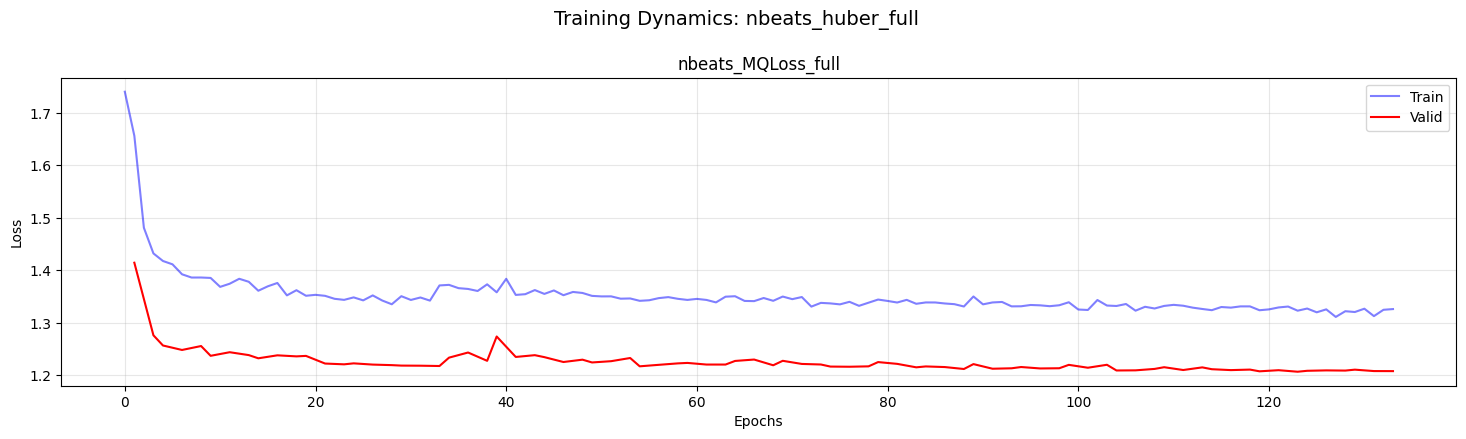

In [30]:
import matplotlib.pyplot as plt

m_df = pd.read_csv("logs/nbeats_mqloss_global/version_0/metrics.csv")
train_m_df = m_df[['epoch', 'train_loss_epoch']].dropna()
valid_m_df = m_df[['epoch', 'valid_loss']].dropna()

plt.figure(figsize=(18, 4))
plt.plot(train_m_df['epoch'], train_m_df['train_loss_epoch'], label='Train', color='blue', alpha=0.5)
plt.plot(valid_m_df['epoch'], valid_m_df['valid_loss'], label='Valid', color='red', linewidth=1.5)

plt.title(f"nbeats_MQLoss_full")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle(f"Training Dynamics: nbeats_huber_full", fontsize=14, y=1.05)
plt.show()

# **5. The Results**
- **Evaluation protocol:** single time split; final 28 days held out for testing.  
- **WRMSSE scope:** item‑level only (Level 12). Full 12‑level WRMSSE is not computed due to RAM/time.  
- **Observation:** LightGBM has higher RMSE (2.1889 vs 2.1814) and higher item‑level WRMSSE (0.8608 vs 0.8568).

In [92]:
print("Calculating RMSE for LightGBM and NBEATSx on Full Test Set...")
results_mqloss_lgbm_full = results_mqloss_stable_full.merge(df_lgbm_glob_preds[['unique_id', 'ds', 'lgbm_pred']], on=['unique_id', 'ds'], how='left')

lgbm_rmse_full = np.sqrt(np.mean((results_mqloss_lgbm_full['y'] - results_mqloss_lgbm_full['lgbm_pred']) ** 2))
mqls_rmse_full = np.sqrt(np.mean((results_mqloss_lgbm_full['y'] - results_mqloss_lgbm_full['NBEATSx_MQLoss_Stable-median']) ** 2))
print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)
print(f"TEST DATASET Global NBEATSx RMSE: {mqls_rmse_full:.4f}")
print("="*40)

# ==========================================
# 3. METRIC 2: WRMSSE (Item-Level Only)
# ==========================================
# Full WRMSSE aggregates 12 levels. Here, I will only compute Level 12 (Item-by-Store) WRMSSE.
print("\nComputing WRMSSE Weights...")

# A. Calculate Scaling Factor (Denominator)
# S_i = RMSE of Naive Forecast on Training Data
# We need the training history for each item to compute this.
# This requires grouping the full training set (59M rows).

print("Computing Scaling Factors...")

# Sort train_df just in case
m5_df = m5_df.sort_values(['unique_id', 'ds'])
# Drop last 28 days to avoid leakage
train_df_metric = m5_df[m5_df['ds'] <= (m5_df['ds'].max() - pd.Timedelta(days=28))] # keep all history except last 28 days

# drop rows where is_available is 0. The scalling factor is only calculated on days where the 'unique_id' item is available.
train_df_metric = train_df_metric[train_df_metric['is_available'] != 0]
# Calculate diff squared for naive forecast (y_t - y_{t-1})^2
train_df_metric['diff_sq'] = train_df_metric.groupby('unique_id')['y'].diff().pow(2)
# Calculate scaling factors (RMSE of naive forecast) per unique_id
scaling_factors = train_df_metric.groupby('unique_id')['diff_sq'].mean().pow(0.5)

print("Computing Dollar Weights...")
# Calculate Dollar Weights
# Weight = Sum of (Sales * Price) in the last 28 days of train_df of each unique_id / Total Sales Revenue in the last 28 days of train_df

last_28_days_train = train_df_metric[train_df_metric['ds'] > (train_df_metric['ds'].max() - pd.Timedelta(days=28))].copy(deep=True)
last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']
total_revenue = last_28_days_train['revenue'].sum()
item_revenue = last_28_days_train.groupby('unique_id')['revenue'].sum()
weights = item_revenue / total_revenue



# C. Calculate RMSSE for our Models
# RMSSE = RMSE / ScalingFactor

print("Computing item-level RMSSE...")
print("Calculating SE...")
# Calculate squared errors for each item for each forcasted day for both models (LightGBM and NBEATSx)
score_df = results_mqloss_lgbm_full.copy(deep=True)
score_df['sq_err_nbeats'] = (score_df['y'] - score_df['NBEATSx_MQLoss_Stable-median'])**2
score_df['sq_err_lgbm'] = (score_df['y'] - score_df['lgbm_pred'])**2

print("Computing MSE...")
# MSE per item
mse_nbeats = score_df.groupby('unique_id')['sq_err_nbeats'].mean()
mse_lgbm = score_df.groupby('unique_id')['sq_err_lgbm'].mean()

print("Computing RMSE...")
# RMSE per item
rmse_nbeats_series = mse_nbeats.pow(0.5)
rmse_lgbm_series = mse_lgbm.pow(0.5)

print("Computing RMSSE...")
# RMSSE (Scaled Error)
rmsse_nbeats = rmse_nbeats_series / scaling_factors
rmsse_lgbm = rmse_lgbm_series / scaling_factors

print("Computing WRMSSE...")
# D. Weighted RMSSE
wrmsse_nbeats = (rmsse_nbeats * weights).sum()
wrmsse_lgbm = (rmsse_lgbm * weights).sum()

print(f"\nWRMSSE (Item-Level):")
print(f"N-BEATSx:  {wrmsse_nbeats:.4f}")
print(f"LightGBM:  {wrmsse_lgbm:.4f}")


# ==========================================
# 4. FINAL VERDICT
# ==========================================
print("-" * 30)
winner = "LightGBM" if wrmsse_lgbm < wrmsse_nbeats else "N-BEATSx"
print(f"WINNER: {winner}")
print("-" * 30)


Calculating RMSE for LightGBM and NBEATSx on Full Test Set...
TEST DATASET Global LightGBM RMSE: 2.1889
TEST DATASET Global NBEATSx RMSE: 2.1814

Computing WRMSSE Weights...
Computing Scaling Factors...
Computing Dollar Weights...
Computing item-level RMSSE...
Calculating SE...
Computing MSE...
Computing RMSE...
Computing RMSSE...
Computing WRMSSE...

WRMSSE (Item-Level):
N-BEATSx:  0.8568
LightGBM:  0.8608
------------------------------
WINNER: N-BEATSx
------------------------------


## Mechanism of Action (Hypothesis): Cross‑Learning

__Why might Global N‑BEATSx outperform on this setup?__

While the numerical gap (WRMSSE 0.8568 vs 0.8608) is modest, it can be meaningful at scale. More importantly, N‑BEATSx reached this performance with **far less manual feature engineering**.

__1) Signal sharing across series (cross‑learning):__ A global model shares parameters across all series. That can help low‑signal / intermittent items by letting the model learn stable effects (weekly seasonality, SNAP cycles, price/availability patterns) from high‑volume series and reuse them where local data is sparse.

__2) Quantile training for skewed demand:__ Retail demand is often zero‑inflated and heavy‑tailed. Training with **MQLoss** encourages the model to represent the conditional distribution. For comparability, we report **RMSE on the median** forecast, while upper quantiles remain useful for service‑level decisions.

__3) What this does *not* prove:__ This section is a plausible mechanism consistent with the diagnostics and metrics here; it is not a causal proof. A stronger validation would include ablations (remove exogenous variables, remove global pooling, change history length) and additional time splits.

__Conclusion:__ In this project framing, the win is as much about **scalable learning + lower feature‑engineering maintenance** as it is about a small metric edge on one split.

**Decision:** N‑BEATSx is selected **for deployment** because it improves RMSE and item‑level WRMSSE on the same horizon.  
**Limitation:** results may differ under full 12‑level WRMSSE or alternative splits.

## Diagnostic Plot 1 — Most Volatile Series (Stress Test)

Purpose: visualize how each model behaves on *spiky, hard-to-forecast* items (high variance).

Important: this is **not** a representative sample. These items are selected *post-hoc* by variance, so this plot is **diagnostic**, not proof of general superiority.

Interpretation focus: whether forecasts track level + turning points, and how badly they miss spikes (tail behavior).

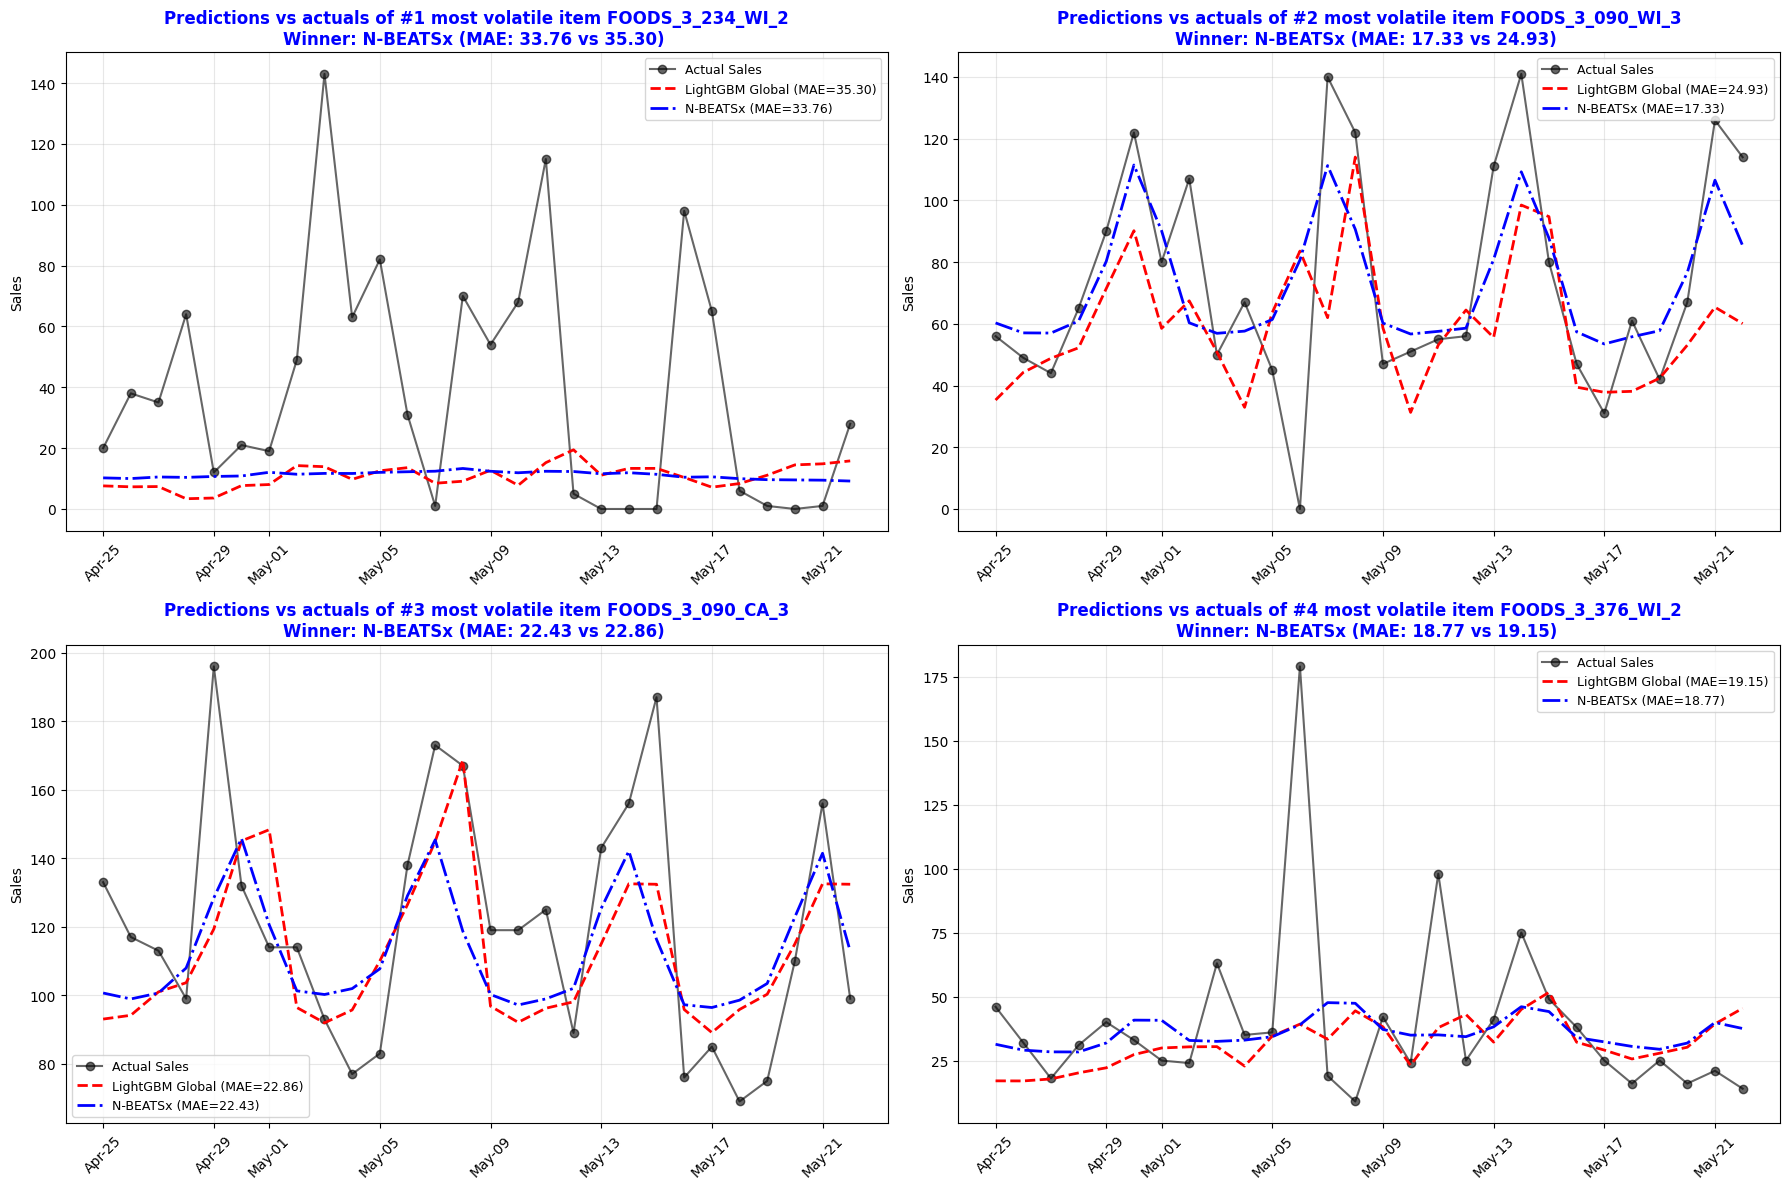

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 5. THE "MONEY PLOT": FORECAST VISUALIZATION (TOP 4 VOLATILE ITEMS)
# ==========================================

# 1. Calculate variance for all items to find the most volatile ones
item_var = score_df.groupby('unique_id')['y'].var()

# 2. Pick the top 4 volatile items
top_volatile_items = item_var.nlargest(4).index

# 3. Setup the 2x2 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
axs = axs.flatten()  # Flatten to easily iterate

# 4. Loop through and plot each one
item_number = 1
for i, (volatile_item, ax) in enumerate(zip(top_volatile_items, axs)):
    subset = score_df[score_df['unique_id'] == volatile_item].copy()
    # Ensure 'ds' is datetime for better axis formatting
    subset['ds'] = pd.to_datetime(subset['ds'])

    # --- Calculate Errors (MAE) ---
    # We use Mean Absolute Error to judge "closeness"
    mae_lgbm = np.mean(np.abs(subset['y'] - subset['lgbm_pred']))
    mae_nbeats = np.mean(np.abs(subset['y'] - subset['NBEATSx_MQLoss_Stable-median']))

    # Determine Winner
    if mae_lgbm < mae_nbeats:
        winner_text = f"Winner: LightGBM (MAE: {mae_lgbm:.2f} vs {mae_nbeats:.2f})"
        title_color = 'red' # Matches LightGBM line color
    else:
        winner_text = f"Winner: N-BEATSx (MAE: {mae_nbeats:.2f} vs {mae_lgbm:.2f})"
        title_color = 'blue' # Matches N-BEATSx line color
    
    # Formatting    
    display_name = volatile_item.replace('_evaluation', '')

    # --- Plotting ---
    # Actual Sales
    ax.plot(subset['ds'], subset['y'], label='Actual Sales', color='black', marker='o', alpha=0.6)
    # LightGBM Predictions
    ax.plot(subset['ds'], subset['lgbm_pred'], label=f'LightGBM Global (MAE={mae_lgbm:.2f})', color='red', linestyle='--', linewidth=2)
    # N-BEATSx Predictions
    ax.plot(subset['ds'], subset['NBEATSx_MQLoss_Stable-median'], label=f'N-BEATSx (MAE={mae_nbeats:.2f})', color='blue', linestyle='-.', linewidth=2)
    
    ax.set_title(f"Predictions vs actuals of #{i+1} most volatile item {display_name}\n{winner_text} ", fontsize=12, color=title_color, fontweight='bold')
    ax.set_ylabel("Sales")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

plt.tight_layout()
plt.show()

### Takeaways (Volatility Stress Test)

- **Both models struggle with true spikes.** On highly intermittent demand, forecasts tend to under‑react to rare surges; this is expected with point/median forecasts and limited event context.
- **N‑BEATSx is slightly more robust on average** in these examples (lower MAE across the selected series), but the visual gap is often smaller than the spike magnitude itself.
- **Interpretation:** This plot is best read as a *failure mode analysis* (tail risk + under‑reaction), not as a generalization claim.
- **Why this matters:** If the business cares more about high‑revenue items than high‑variance items, we should validate improvements using revenue‑weighted metrics (WRMSSE), not only “spike hunting.”

## Diagnostic Plot 2 — Highest WRMSSE-Weight Items (Business Relevance)

Purpose: visualize performance on items that dominate WRMSSE (revenue-weighted impact).

This plot connects model choice to business value: small error differences on high-weight items matter more than large differences on low-weight items.

Expectation: The results will be mixed. The decision is based on **aggregate WRMSSE/RMSE**, with these panels serving as interpretability checks.

Plotting Top 4 Items by WRMSSE Weight (Comparing Model Accuracy)...


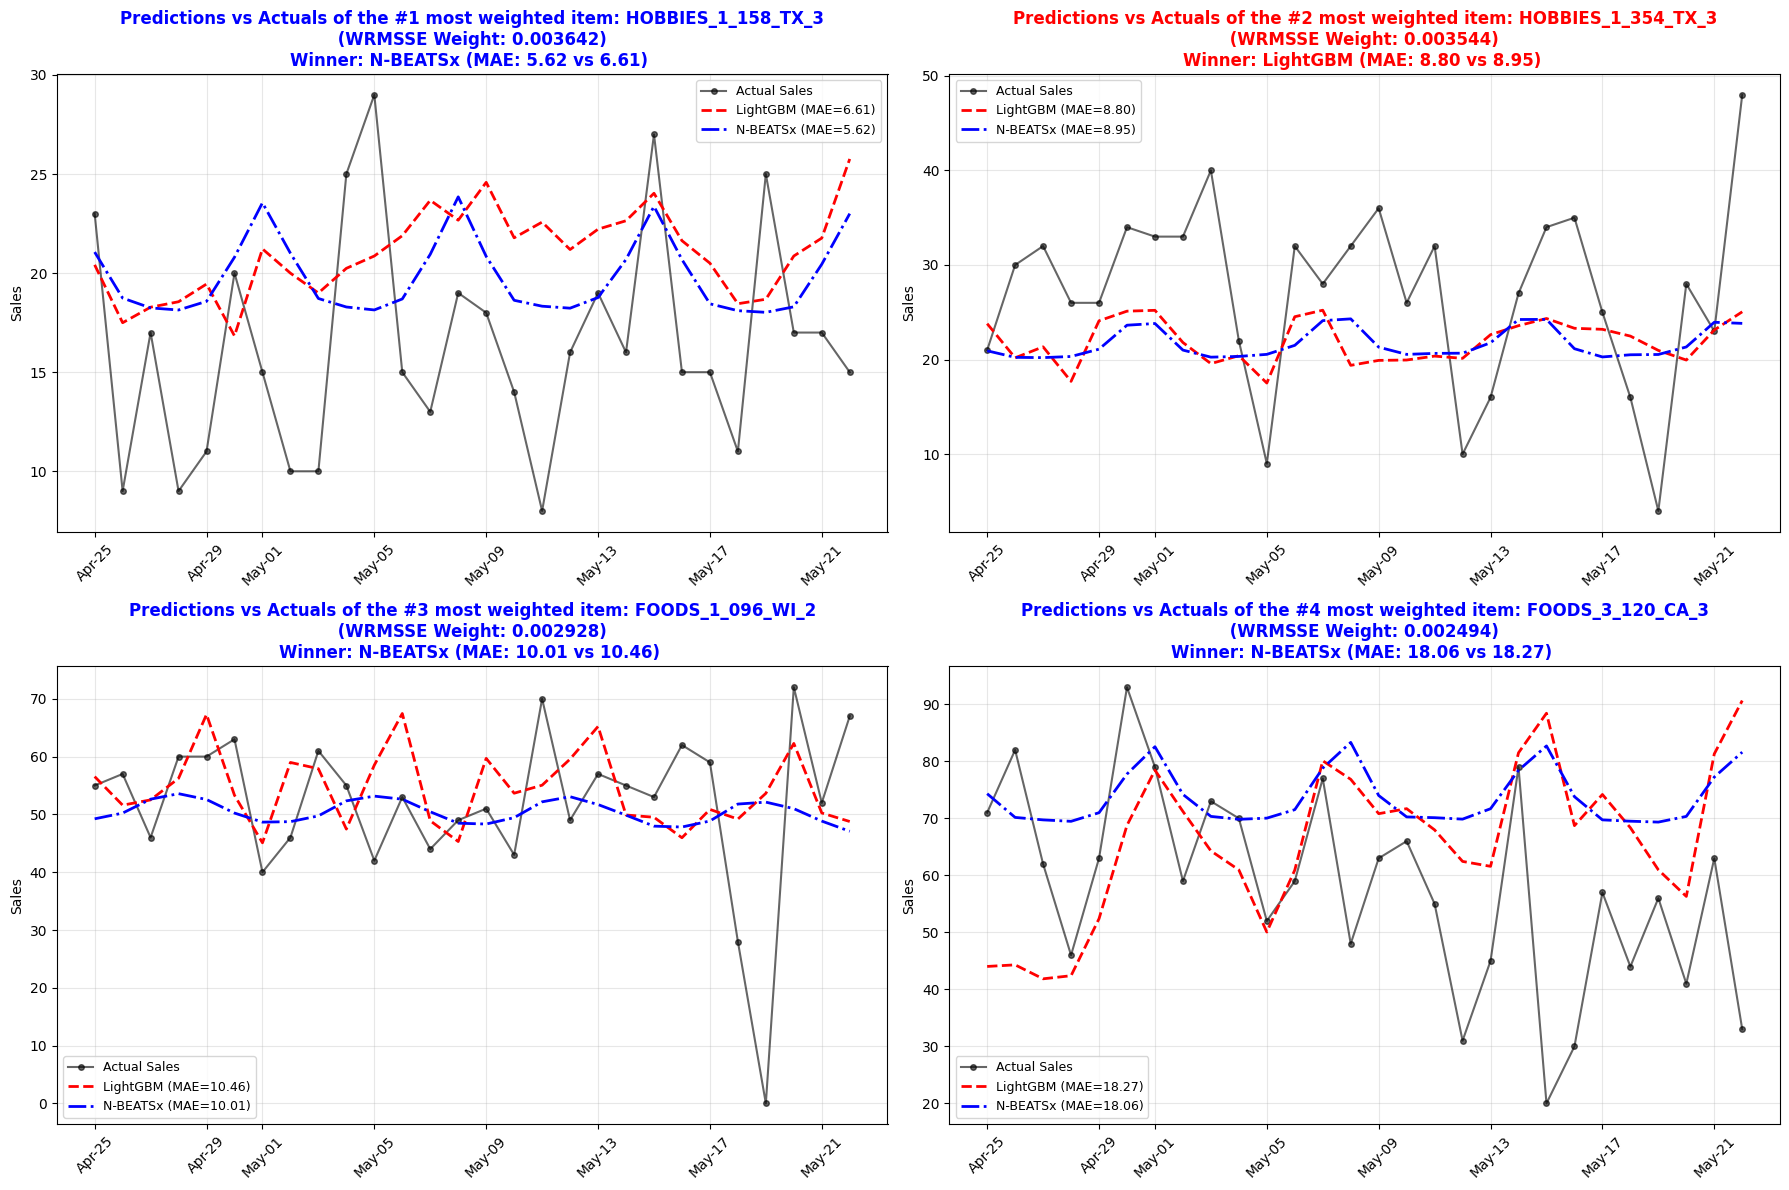

In [81]:
# ==========================================
# 6. FORECAST VISUALIZATION (TOP 4 WEIGHTED ITEMS - WITH WINNER)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# 1. Identify Top 4 Items by WRMSSE Weight
top_weighted_items = weights.nlargest(4).index

print(f"Plotting Top 4 Items by WRMSSE Weight (Comparing Model Accuracy)...")

# 2. Setup the 2x2 Figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# 3. Loop and Plot
for i, (item, ax) in enumerate(zip(top_weighted_items, axes)):
    subset = score_df[score_df['unique_id'] == item]
    
    # --- Calculate Errors (MAE) ---
    # We use Mean Absolute Error to judge "closeness"
    mae_lgbm = np.mean(np.abs(subset['y'] - subset['lgbm_pred']))
    mae_nbeats = np.mean(np.abs(subset['y'] - subset['NBEATSx_MQLoss_Stable-median']))

    # Determine Winner
    if mae_lgbm < mae_nbeats:
        winner_text = f"Winner: LightGBM (MAE: {mae_lgbm:.2f} vs {mae_nbeats:.2f})"
        title_color = 'red' # Matches LightGBM line color
    else:
        winner_text = f"Winner: N-BEATSx (MAE: {mae_nbeats:.2f} vs {mae_lgbm:.2f})"
        title_color = 'blue' # Matches N-BEATSx line color

    # --- Plotting ---
    # Actual Sales
    ax.plot(subset['ds'], subset['y'], label='Actual Sales', color='black', marker='o', alpha=0.6, markersize=4)
    
    # LightGBM
    ax.plot(subset['ds'], subset['lgbm_pred'], label=f'LightGBM (MAE={mae_lgbm:.2f})', color='red', linestyle='--', linewidth=2)
    
    # N-BEATSx
    ax.plot(subset['ds'], subset['NBEATSx_MQLoss_Stable-median'], label=f'N-BEATSx (MAE={mae_nbeats:.2f})', color='blue', linestyle='-.', linewidth=2)
    
    # Formatting
    item_weight = weights[item]
    
    # Clean the item name specifically for the title
    display_name = item.replace('_evaluation', '')
    
    ax.set_title(f"Predictions vs Actuals of the #{i+1} most weighted item: {display_name}\n (WRMSSE Weight: {item_weight:.6f}) \n{winner_text} ", fontsize=12, color=title_color, fontweight='bold')
    ax.set_ylabel("Sales")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

plt.tight_layout()
plt.show()

### Takeaways (Business‑Weighted Items)

- These items carry the largest WRMSSE weights, so **small absolute errors can dominate the overall score**.
- Results are **mixed by design** (one model will not win every series), but N‑BEATSx is competitive and often better on the highest‑impact items in this sample.
- **What this supports:** the model choice is justified by aggregate outcomes (RMSE + item‑level WRMSSE) *and* by sanity‑checking performance on the series that matter most commercially.
- **Production framing:** the goal is not to “win every SKU,” but to improve weighted accuracy while reducing feature‑engineering maintenance burden.

In [13]:
import pandas as pd
import gc

# Paths (Adjust if your data is in a different folder)
CAL_PATH = '../data/calendar.csv'
PRICE_PATH = '../data/sell_prices.csv'
SALES_PATH = '../data/sales_train_evaluation.csv'

def calculate_m5_annual_revenue():
    print("Loading Calendar...")
    cal = pd.read_csv(CAL_PATH)
    cal['date'] = pd.to_datetime(cal['date'])
    
    # Filter for full years only (2012, 2013, 2014, 2015)
    # 2011 is partial (starts Jan 29), 2016 is partial (ends mid-year)
    years_to_keep = [2012, 2013, 2014, 2015]
    cal = cal[cal['date'].dt.year.isin(years_to_keep)]
    
    # Create a map: d_xxx -> wm_yr_wk (to link sales to prices)
    # and d_xxx -> year (to group by year)
    d_cols = cal['d'].tolist()
    d_to_wk = dict(zip(cal['d'], cal['wm_yr_wk']))
    d_to_year = dict(zip(cal['d'], cal['date'].dt.year))
    
    print("Loading Prices...")
    prices = pd.read_csv(PRICE_PATH)
    
    print("Calculating Revenue (Store by Store to save RAM)...")
    sales_df = pd.read_csv(SALES_PATH)
    stores = sales_df['store_id'].unique()
    
    total_revenue_by_year = {y: 0 for y in years_to_keep}
    
    for store in stores:
        print(f"Processing {store}...")
        
        # 1. Filter Sales for this store and relevant days
        store_sales = sales_df[sales_df['store_id'] == store][['item_id'] + d_cols]
        
        # 2. Melt to long format: [item_id, d, qty]
        store_melt = store_sales.melt(id_vars=['item_id'], var_name='d', value_name='qty')
        store_melt = store_melt[store_melt['qty'] > 0] # Optimization: Ignore 0 sales
        
        # 3. Map d -> wm_yr_wk and d -> year
        store_melt['wm_yr_wk'] = store_melt['d'].map(d_to_wk)
        store_melt['year'] = store_melt['d'].map(d_to_year)
        
        # 4. Merge Prices: [item_id, wm_yr_wk] -> price
        # Filter prices to just this store to speed up merge
        store_prices = prices[prices['store_id'] == store][['item_id', 'wm_yr_wk', 'sell_price']]
        store_melt = store_melt.merge(store_prices, on=['item_id', 'wm_yr_wk'], how='left')
        
        # 5. Calculate Revenue
        store_melt['revenue'] = store_melt['qty'] * store_melt['sell_price']
        
        # 6. Group by Year and add to totals
        year_sums = store_melt.groupby('year')['revenue'].sum()
        for y in years_to_keep:
            total_revenue_by_year[y] += year_sums.get(y, 0)
            
        del store_melt, store_sales, store_prices
        gc.collect()

    # Final Average
    avg_revenue = sum(total_revenue_by_year.values()) / len(years_to_keep)
    
    print("-" * 30)
    print("TOTAL REVENUE BY YEAR:")
    for y, rev in total_revenue_by_year.items():
        print(f"{y}: ${rev:,.2f}")
    print("-" * 30)
    print(f"AVERAGE ANNUAL REVENUE (2012-2015): ${avg_revenue:,.2f}")
    
    return avg_revenue

# Run it
avg_rev = calculate_m5_annual_revenue()

Loading Calendar...
Loading Prices...
Calculating Revenue (Store by Store to save RAM)...
Processing CA_1...
Processing CA_2...
Processing CA_3...
Processing CA_4...
Processing TX_1...
Processing TX_2...
Processing TX_3...
Processing WI_1...
Processing WI_2...
Processing WI_3...
------------------------------
TOTAL REVENUE BY YEAR:
2012: $32,649,200.84
2013: $35,923,373.31
2014: $37,861,913.19
2015: $42,416,456.61
------------------------------
AVERAGE ANNUAL REVENUE (2012-2015): $37,212,735.99


# Back-of-the-Envelope ROI & Business Impact (Illustrative)

__Accuracy result (this evaluation protocol):__ item‑level WRMSSE improved from **0.8608 → 0.8568** (~0.5% relative), alongside a small RMSE improvement.

__Revenue context (from M5 data):__ total revenue across all 10 stores for fiscal year 2015 is about **$42.4M** (computed in the cell above).

__How to interpret “ROI”:__ Translating forecast-metric gains into dollars requires assumptions about how forecast error drives inventory and service levels. A common heuristic is that a *small* relative reduction in weighted error can translate into a *small* relative reduction in safety stock, write-offs, or lost-sales exposure — but the relationship is not strictly linear and varies by category and policy.

__Illustrative range (not a claim):__ If a **0.5%** improvement in weighted accuracy translated into **0.2%–1.0%** improvement in inventory efficiency on comparable operations, that corresponds to roughly **$85k–$425k/year** on this dataset’s revenue scale.

__Scaling note:__ Extending this to a larger retailer (e.g., hundreds of stores) is **directional** only. A more defensible estimate would tie quantile forecasts to explicit service-level targets and simulate inventory policies.

__Engineering ROI (often more reliable):__
- LightGBM’s performance depends on ongoing maintenance of lag/rolling features and calendar joins.
- The global N‑BEATSx setup reduces that feature-engineering surface area, which can lower operational risk and iteration time in production.